In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json, os

In [9]:
RESULT_FOLDER = 'results2'
as_results = {}
for file in os.listdir(RESULT_FOLDER):
    if not file.startswith("as_"):
        continue
    name_split = file.replace("as_", "").replace("-forest", "").split("-")
    fold = name_split[-1]
    feature_names = "-".join(name_split[:-1])
    with open(os.path.join(RESULT_FOLDER, file)) as f:
        content = json.load(f)
    if feature_names not in as_results:
        as_results[feature_names] = []
    as_results[feature_names].append((content['clf_time'] - content['clf_vbs']) / (content['cp-sat_time'] - content['clf_vbs']))

order = {
    'wl-3' : 0,
    'wl-5' : 1,
    'wl-7' : 2,

    'wle-3' : 3,
    'wle-3-raw' : 4,
    'wle-3-limited' : 5,
    'wle-5' : 6,
    'wle-7' : 7,

    'wln-3' : 8,
    'wln-5' : 9,
    'wln-7' : 10,

    'wlne-3' : 11,
    'wlne-5' : 12,
    'wlne-7' : 13,

    'fzn2feat':14
}
as_results_plot = {k:v for k,v in sorted(as_results.items(), key=lambda x: order[x[0]]) if not 'raw' in k and not 'limited' in k}

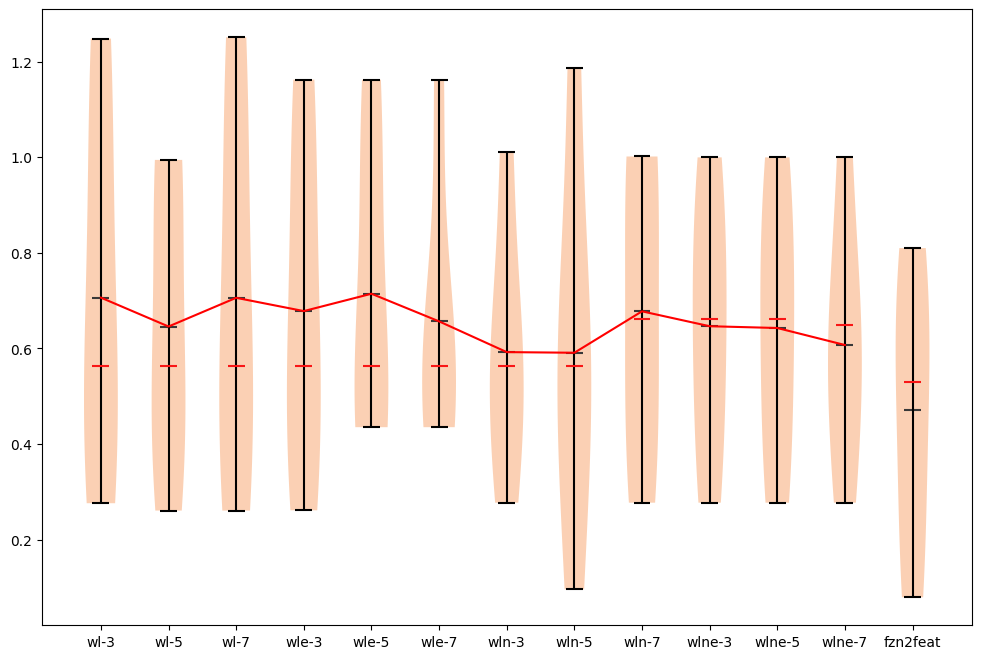

In [12]:
plt.figure(figsize=(12,8))
violin_parts = plt.violinplot(as_results_plot.values(), showmeans=True, showmedians=True)

for pc in violin_parts['bodies']:
    pc.set_facecolor('#f46607')
violin_parts['cbars'].set_color('black')
violin_parts['cmins'].set_color('black')
violin_parts['cmaxes'].set_color('black')
violin_parts['cmaxes'].set_color('black')
violin_parts['cmedians'].set_color('#f91616')
violin_parts['cmeans'].set_color('#383838')

plt.plot([i for i in range(1, len(as_results_plot.keys()))], [np.mean(v) for k, v in as_results_plot.items() if k != 'fzn2feat'], c='red')

plt.xticks([i for i in range(1, len(as_results_plot.keys())+1)], as_results_plot.keys())
plt.show()

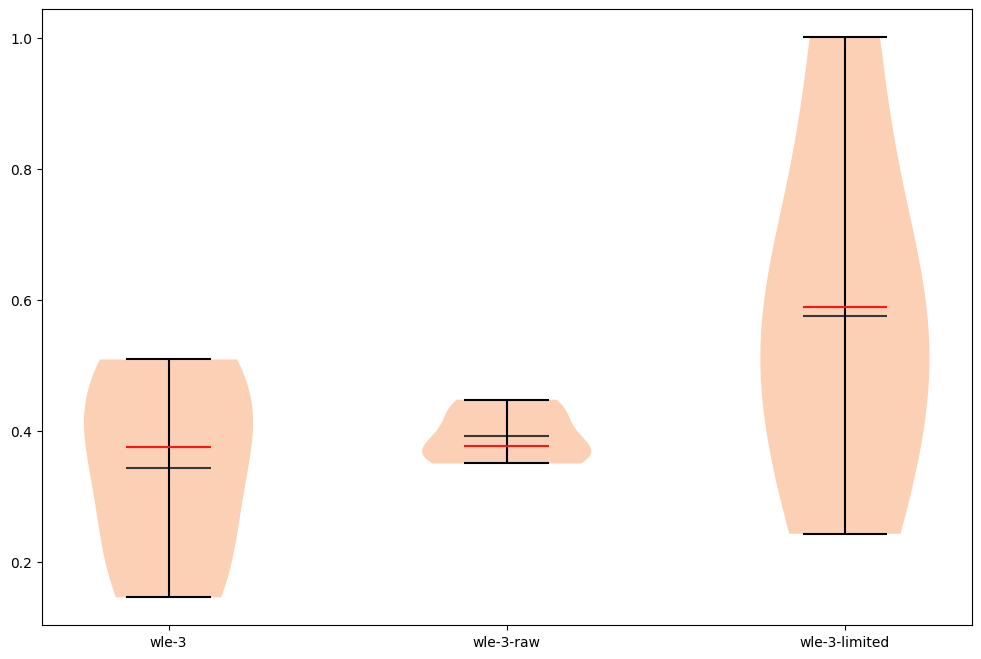

In [ ]:
plt.figure(figsize=(12,8))
comparisons = {k:v for k,v in sorted(as_results.items(), key=lambda x: order[x[0]]) if 'wle-3' in k}


violin_parts = plt.violinplot(comparisons.values(), showmeans=True, showmedians=True)

for pc in violin_parts['bodies']:
    pc.set_facecolor('#f46607')
violin_parts['cbars'].set_color('black')
violin_parts['cmins'].set_color('black')
violin_parts['cmaxes'].set_color('black')
violin_parts['cmaxes'].set_color('black')
violin_parts['cmedians'].set_color('#f91616')
violin_parts['cmeans'].set_color('#383838')

plt.xticks([i for i in range(1, len(comparisons.keys())+1)], comparisons.keys())
plt.show()

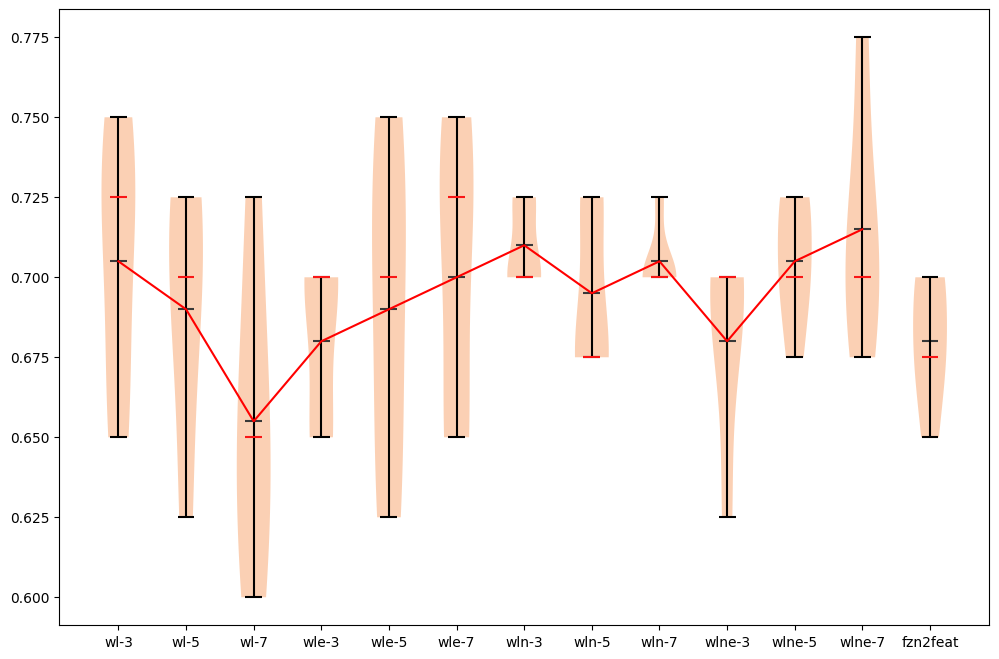

In [14]:
accuracy_result = {}
for file in os.listdir(RESULT_FOLDER):
    if not file.startswith("as_"):
        continue
    name_split = file.replace("as_", "").replace("-forest", "").split("-")
    fold = name_split[-1]
    feature_names = "-".join(name_split[:-1])
    with open(os.path.join(RESULT_FOLDER, file)) as f:
        content = json.load(f)
    if feature_names not in accuracy_result:
        accuracy_result[feature_names] = []
    accuracy_result[feature_names].append(content['accuracy'])

order = {
    'wl-3' : 0,
    'wl-5' : 1,
    'wl-7' : 2,

    'wle-3' : 3,
    'wle-3-raw' : 4,
    'wle-3-limited' : 5,
    'wle-5' : 6,
    'wle-7' : 7,

    'wln-3' : 8,
    'wln-5' : 9,
    'wln-7' : 10,

    'wlne-3' : 11,
    'wlne-5' : 12,
    'wlne-7' : 13,

    'fzn2feat':14
}
accuracy_result_plot = {k:v for k,v in sorted(accuracy_result.items(), key=lambda x: order[x[0]]) if not 'raw' in k and not 'limited' in k}

plt.figure(figsize=(12,8))
violin_parts = plt.violinplot(accuracy_result_plot.values(), showmeans=True, showmedians=True)

for pc in violin_parts['bodies']:
    pc.set_facecolor('#f46607')
violin_parts['cbars'].set_color('black')
violin_parts['cmins'].set_color('black')
violin_parts['cmaxes'].set_color('black')
violin_parts['cmaxes'].set_color('black')
violin_parts['cmedians'].set_color('#f91616')
violin_parts['cmeans'].set_color('#383838')

plt.plot([i for i in range(1, len(accuracy_result_plot.keys()))], [np.mean(v) for k, v in accuracy_result_plot.items() if k != 'fzn2feat'], c='red')

plt.xticks([i for i in range(1, len(accuracy_result_plot.keys())+1)], accuracy_result_plot.keys())
plt.show()

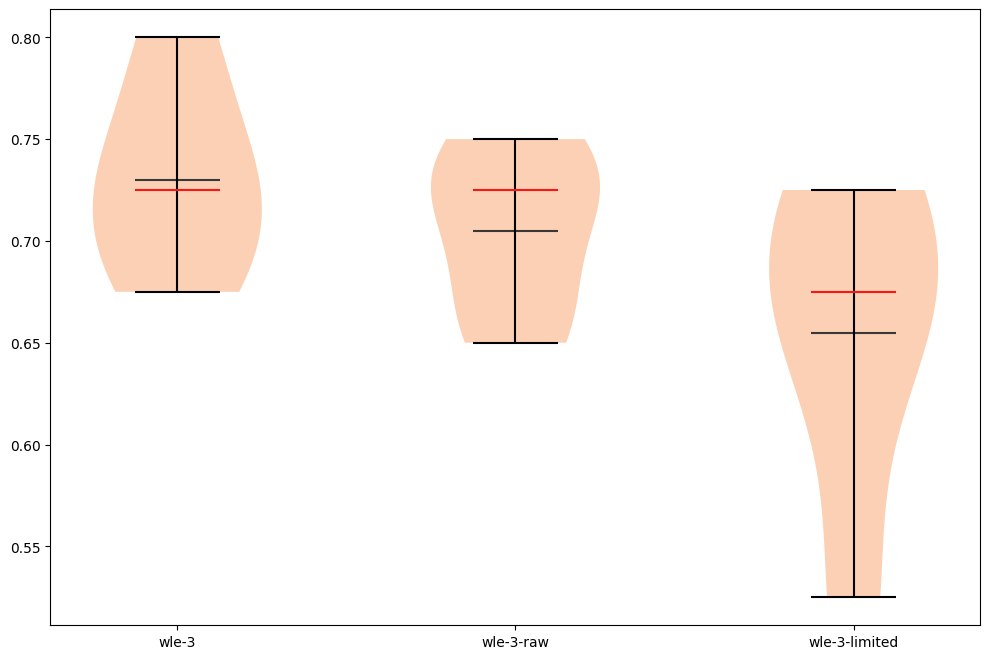

In [22]:
plt.figure(figsize=(12,8))
comparisons_accuracy = {k:v for k,v in sorted(accuracy_result.items(), key=lambda x: order[x[0]]) if 'wle-3' in k}


violin_parts = plt.violinplot(comparisons_accuracy.values(), showmeans=True, showmedians=True)

for pc in violin_parts['bodies']:
    pc.set_facecolor('#f46607')
violin_parts['cbars'].set_color('black')
violin_parts['cmins'].set_color('black')
violin_parts['cmaxes'].set_color('black')
violin_parts['cmaxes'].set_color('black')
violin_parts['cmedians'].set_color('#f91616')
violin_parts['cmeans'].set_color('#383838')

plt.xticks([i for i in range(1, len(comparisons_accuracy.keys())+1)], comparisons_accuracy.keys())
plt.show()